<a href="https://colab.research.google.com/github/Julian6262/the_founder/blob/main/%D0%94%D0%97-38.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

В домашней работе вам необходимо выполнить одно из трёх заданий на выбор:

**Задание 1. На 3 балла:**

Создайте переводчик с одного языка на другой, отличные от тех, что использовались в уроке. Сравните результаты переводов для 4-х, 6-и и 8-и голов (`num_heads`), при одинаковых прочих параметрах. Сделайте выводы письменно в колабе.

**Задание 2. На 4 балла:**

Постройте трансформер для задачи `question answering`. Трансформер должен работать по принципу чат-бота: принимать на вход вопрос, и генерировать ответ на этот вопрос. В качестве датасета используйте `web_questions` из tensorflow_datasets.

Меняя гиперпараметры, добейтесь адекватного качества ответов.

**Задание 3. На 5 баллов:**

Постройте трансформер для задачи `question answering`. Трансформер должен работать по принципу чат-бота: принимать на вход вопрос, и генерировать ответ на этот вопрос.

В качестве датасета необходимо использовать русско-язычный диалог от Денчика с HuggingFace:

```python
dataset = load_dataset('Den4ikAI/russian_dialogues', split='train', )
```

Меняя гиперпараметры, добейтесь адекватного качества ответов.

На 5 баллов задание выполняется самостоятельно без помощи куратора!

In [ ]:
# Установим свежую версию TensorFlow для поддержки слоя `tf.keras.layers.MultiHeadAttention`.
!apt install --allow-change-held-packages libcudnn8=8.1.0.77-1+cuda11.2
!pip uninstall -y -q tensorflow keras tensorflow-estimator tensorflow-text
!pip install protobuf~=3.20.3
!pip install -q tensorflow_datasets
!pip install -q -U tensorflow-text tensorflow

In [ ]:
!pip install datasets

In [ ]:
# Линейная алгебра
import numpy as np

# Вывод графиков
import matplotlib.pyplot as plt

# Фреймворк Tensorflow
import tensorflow as tf

import tensorflow_text as text
# Регулярные выражения
import re

# Файловая система
import pathlib

# Токенизатор
from tensorflow_text.tools.wordpiece_vocab import bert_vocab_from_dataset as bert_vocab

from datasets import load_dataset

# Отключим мешаюшие предупреждения
import warnings
warnings.filterwarnings("ignore")

In [ ]:
dataset = load_dataset('Den4ikAI/russian_dialogues', split='train', )

README.md:   0%|          | 0.00/951 [00:00<?, ?B/s]

dataset.jsonl:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

Generating train split:   0%|          | 0/2477321 [00:00<?, ? examples/s]

In [ ]:
len(dataset)

2477321

In [ ]:
dataset = dataset.take(110000)

In [ ]:
for row in dataset.take(5):
    print(f'Вопрос: {row["question"]}')
    print(f'Ответ: {row["answer"]}')
    print(f'Релевантность: {row["relevance"]}\n')

Вопрос: как дела?
Ответ: там хорошо
Релевантность: 0

Вопрос: вы кефир пачему не кушаете, не любите?
Ответ: я ряженку лучше люблю.
Релевантность: 1

Вопрос: если в расходную накладную забить дури и выкурить, то получится приходный документ?
Ответ: особенно когда придет комиссия проверять документацию
Релевантность: 1

Вопрос: покажись в шапке
Ответ: ды щаз приветик
Релевантность: 0

Вопрос: давай не будем об этом
Ответ: давай поговорим о чем-нибудь другом
Релевантность: 1



In [ ]:
# Выбрать только релевантный диалоги

relevance_dataset = dataset.filter(lambda row: row['relevance'] == 1)

Filter:   0%|          | 0/110000 [00:00<?, ? examples/s]

In [ ]:
len(relevance_dataset)

61130

In [ ]:
# Удалить пустые строки

relevance_dataset = relevance_dataset.filter(lambda row: row['question'] is not None and row['answer'] is not None)

Filter:   0%|          | 0/61130 [00:00<?, ? examples/s]

In [ ]:
len(relevance_dataset)

61113

In [ ]:
for row in relevance_dataset.take(5):
    print(f'Вопрос: {row["question"]}')
    print(f'Ответ: {row["answer"]}')
    print(f'Релевантность: {row["relevance"]}\n')

Вопрос: вы кефир пачему не кушаете, не любите?
Ответ: я ряженку лучше люблю.
Релевантность: 1

Вопрос: если в расходную накладную забить дури и выкурить, то получится приходный документ?
Ответ: особенно когда придет комиссия проверять документацию
Релевантность: 1

Вопрос: давай не будем об этом
Ответ: давай поговорим о чем-нибудь другом
Релевантность: 1

Вопрос: препарат для лечения сильно понижает давление. что порекомендуете?
Ответ: чтоб не сильно? или что? препарат принимай и кофе пей
Релевантность: 1

Вопрос: мужчина, если ты занюхиваешь волосами соседки, то какой аромат предпочитаешь?
Ответ: предпочитаю соседкиными пирогами закусывать. -
Релевантность: 1



In [ ]:
examples = relevance_dataset.train_test_split(test_size=0.2)

In [ ]:
train_examples, val_examples = examples['train'], examples['test']

In [ ]:
print('Размер обучающей выборки: ', len(train_examples))
print('Размер валидационной выборки: ', len(val_examples))

Размер обучающей выборки:  48890
Размер валидационной выборки:  12223


In [ ]:
del examples, relevance_dataset, dataset

In [ ]:
VOCAB_SIZE = 8000
# Параметры токенизатора (lower_case - приводим к нижнему регистру)
bert_tokenizer_params=dict(lower_case=True)

# Определяем токены, с которыми работает токенизатор
# [START] - начало строки
# [END]   - конец строки
# [UNK]   - неизвестное слово
# [PAD]   - используется для выравнивания длин всех предложений
reserved_tokens=["[PAD]", "[UNK]", "[START]", "[END]"]

bert_vocab_args = dict(
    # Желаемый размер словаря
    vocab_size = VOCAB_SIZE,
    # Токены включаемые в словарь
    reserved_tokens=reserved_tokens,
    # Аргументы для `text.BertTokenizer`
    bert_tokenizer_params=bert_tokenizer_params,

    # Аргументы для `wordpiece_vocab.wordpiece_tokenizer_learner_lib.learn`
    learn_params={}, # не используем, но определяем чтобы не было ошибок
)

In [ ]:
# Two tensors can be combined into one Dataset object.
question = tf.constant(train_examples['question'])
answer = tf.constant(train_examples['answer'])
train_dataset = tf.data.Dataset.from_tensor_slices((question, answer))

question = tf.constant(val_examples['question'])
answer = tf.constant(val_examples['answer'])
val_dataset = tf.data.Dataset.from_tensor_slices((question, answer))

In [ ]:
print('Размер обучающей выборки: ', len(train_dataset))
print('Размер валидационной выборки: ', len(val_dataset))

Размер обучающей выборки:  48890
Размер валидационной выборки:  12223


In [ ]:
for question_examples, answer_examples in train_dataset.batch(3).take(1):
  print('Вопросы:')
  print()
  for pt in question_examples.numpy():
    print(pt.decode('utf-8'))
  print()

  print('Ответы:')
  print()
  for en in answer_examples.numpy():
    print(en.decode('utf-8'))

Вопросы:

а ведь лучше чтоб президентом был покемон?
почему в браке многие женщины внешне дурнею
почему муж стал изменять жене

Ответы:

то-то песков не советовал ловить покемонов в кремле что-то знает
вина здесь на неопытности обоих и неумении выстроить быт так чтобы каждому хватало времени на себя. ведь не секрет что и мужчины дурнеют после брака. посудите сами женщина в браке проснувшись с утра должна приготовить завтрак плюс собрать себя на работу, в обед обеспечить мужа обедом, если он не ест в столовой, и на ужин придя с работы она опять должна что-то готовить. а если есть дети, то времени на себя совсем не остается. потом женщины к этому режиму привыкают, а на внешности любая измотанность плохо будет сказываться. поэтому если хотите дать своей женщине время на себя, чтобы она была в форме, дайте ей это время и не бойтесь помочь ей по мелким бытовым вопросам.
стал изменять потому, что пропало уважение мужа как к себе, так и к своей жене. других причин, как по мне, быть вообще не 

In [ ]:
train_answer = train_dataset.map(lambda question, answer: answer)
train_question = train_dataset.map(lambda question, answer: question)

In [ ]:
%%time
question_vocab = bert_vocab.bert_vocab_from_dataset(
    train_question.batch(1000).prefetch(2),
    **bert_vocab_args
)

CPU times: user 2min 40s, sys: 789 ms, total: 2min 41s
Wall time: 2min 39s


In [ ]:
print(question_vocab[:10])
print(question_vocab[100:110])
print(question_vocab[1000:1010])
print(question_vocab[-10:])

['[PAD]', '[UNK]', '[START]', '[END]', '!', ',', '-', '.', ':', ';']
['какои', 'из', 'может', '##у', 'меня', 'мне', 'где', 'нет', 'лучше', 'будет']
['##вается', '##ве', '##кие', '##тки', '##чик', 'будто', 'ваших', 'внимание', 'вчера', 'дом']
['##;', '##?', '##b', '##f', '##i', '##j', '##k', '##q', '##z', '##ъ']


In [ ]:
def write_vocab_file(filepath, vocab):
  with open(filepath, 'w') as f:
    for token in vocab:
      print(token, file=f)

In [ ]:
write_vocab_file('question_vocab.txt', question_vocab)

In [ ]:
%%time
answer_vocab = bert_vocab.bert_vocab_from_dataset(
    train_answer.batch(1000).prefetch(2),
    **bert_vocab_args
)

CPU times: user 2min 47s, sys: 1.08 s, total: 2min 49s
Wall time: 2min 47s


In [ ]:
print(answer_vocab[:10])
print(answer_vocab[100:110])
print(answer_vocab[1000:1010])
print(answer_vocab[-10:])

['[PAD]', '[UNK]', '[START]', '[END]', '!', ',', '-', '.', ':', ';']
['же', 'они', 'уже', 'бы', 'надо', 'вот', 'лучше', '##у', 'просто', 'он']
['надеюсь', 'ответах', 'пол', 'хотелось', '##лить', '##ческии', '##щим', 'всякие', 'игры', 'красота']
['##k', '##l', '##m', '##q', '##u', '##v', '##w', '##x', '##z', '##ъ']


In [ ]:
write_vocab_file('answer_vocab.txt', answer_vocab)

In [ ]:
question_tokenizer = text.BertTokenizer('question_vocab.txt', **bert_tokenizer_params)
answer_tokenizer = text.BertTokenizer('answer_vocab.txt', **bert_tokenizer_params)

In [ ]:
print('Отберем строки для примера:')
for question_examples, answer_examples in train_dataset.batch(3).take(1):
  for ex in answer_examples:
    print(ex.numpy().decode('utf8'))

Отберем строки для примера:
то-то песков не советовал ловить покемонов в кремле что-то знает
вина здесь на неопытности обоих и неумении выстроить быт так чтобы каждому хватало времени на себя. ведь не секрет что и мужчины дурнеют после брака. посудите сами женщина в браке проснувшись с утра должна приготовить завтрак плюс собрать себя на работу, в обед обеспечить мужа обедом, если он не ест в столовой, и на ужин придя с работы она опять должна что-то готовить. а если есть дети, то времени на себя совсем не остается. потом женщины к этому режиму привыкают, а на внешности любая измотанность плохо будет сказываться. поэтому если хотите дать своей женщине время на себя, чтобы она была в форме, дайте ей это время и не бойтесь помочь ей по мелким бытовым вопросам.
стал изменять потому, что пропало уважение мужа как к себе, так и к своей жене. других причин, как по мне, быть вообще не может, вроде жена стала скучная, много скандалит и все такое. это уже второстепенные попытки оправдать измену

In [ ]:
# Прогоним примеры через BertTokenizer.tokenize метод. Он вернет нам объект tf.RaggedTensor с осями (batch, word, word-piece)

# Токенизируем примеры и получаем тензор формы (batch, word, word-piece)
token_batch = answer_tokenizer.tokenize(answer_examples)
# Объединяем оси word и word-piece и получаем тензор формы (batch, tokens)
token_batch = token_batch.merge_dims(-2,-1)

print('Токенизируем отобранные строки:')
for ex in token_batch.to_list():
  print(ex)

Токенизируем отобранные строки:
[72, 6, 72, 51, 4099, 409, 68, 7000, 4840, 5535, 83, 266, 4826, 128, 39, 3272, 513, 69, 6, 72, 633]
[1902, 545, 71, 68, 5336, 1265, 221, 2120, 45, 68, 3210, 1208, 143, 6578, 5872, 6676, 78, 137, 1122, 57, 4758, 2501, 411, 71, 136, 7, 275, 68, 4322, 69, 45, 247, 41, 3407, 301, 371, 200, 1849, 7, 83, 1729, 2997, 289, 321, 39, 2097, 237, 189, 375, 216, 5956, 53, 1150, 717, 5623, 3713, 1224, 5656, 136, 71, 571, 5, 39, 5572, 3503, 189, 1440, 837, 647, 5572, 119, 5, 74, 109, 68, 6732, 39, 2837, 714, 5, 45, 71, 3333, 160, 4095, 53, 663, 133, 634, 717, 69, 6, 72, 1352, 7, 37, 74, 84, 497, 5, 72, 411, 71, 136, 332, 68, 1034, 7, 151, 242, 46, 673, 2597, 107, 4300, 734, 5, 37, 71, 3064, 803, 123, 2154, 6584, 436, 347, 98, 53, 2627, 91, 7, 249, 74, 1127, 1048, 340, 800, 161, 71, 136, 5, 137, 133, 273, 39, 2844, 5, 1479, 171, 376, 70, 161, 45, 68, 3236, 1086, 1019, 376, 83, 48, 961, 1464, 6676, 1519, 3926, 90, 7]
[1874, 4230, 118, 5, 69, 237, 2243, 162, 1339, 647, 75

In [ ]:
# Для того, чтобы повторно собрать слова из извлеченных токенов, необходимо использовать BertTokenizer.detokenize метод:

words = answer_tokenizer.detokenize(token_batch)
print('Проверим обратное преобразование:')

# Объединение полученного тензора в текст, объединяем пробелами
for line in tf.strings.reduce_join(words, separator=' ', axis=-1):
    print(line.numpy().decode('utf8'))

Проверим обратное преобразование:
то - то песков не советовал ловить покемонов в кремле что - то знает
вина здесь на неопытности обоих и неумении выстроить быт так чтобы каждому хватало времени на себя . ведь не секрет что и мужчины дурнеют после брака . посудите сами женщина в браке проснувшись с утра должна приготовить завтрак плюс собрать себя на работу , в обед обеспечить мужа обедом , если он не ест в столовои , и на ужин придя с работы она опять должна что - то готовить . а если есть дети , то времени на себя совсем не остается . потом женщины к этому режиму привыкают , а на внешности любая измотанность плохо будет сказываться . поэтому если хотите дать своеи женщине время на себя , чтобы она была в форме , даите еи это время и не боитесь помочь еи по мелким бытовым вопросам .
стал изменять потому , что пропало уважение мужа как к себе , так и к своеи жене . других причин , как по мне , быть вообще не может , вроде жена стала скучная , много скандалит и все такое . это уже второс

Нам необходимо оценить как распределяются токены по примерам:

In [ ]:
lengths = []

for question_examples, answer_examples in train_dataset.batch(1024):
  question_tokens = question_tokenizer.tokenize(question_examples)
  lengths.append(question_tokens.row_lengths())

  answer_tokens = answer_tokenizer.tokenize(answer_examples)
  lengths.append(answer_tokens.row_lengths())

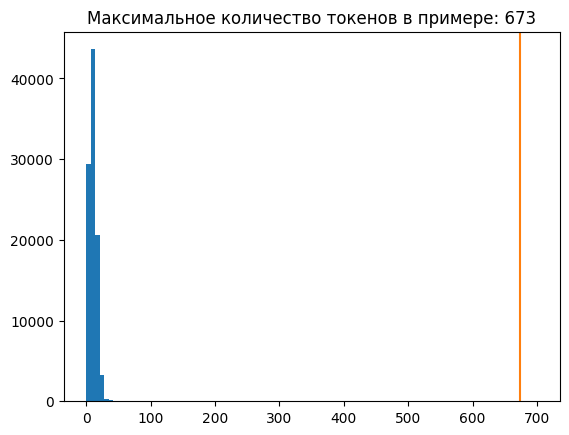

In [ ]:
all_lengths = np.concatenate(lengths)

plt.hist(all_lengths, np.linspace(0, 700, 101))
plt.ylim(plt.ylim())
max_length = max(all_lengths)
plt.plot([max_length, max_length], plt.ylim())
plt.title(f'Максимальное количество токенов в примере: {max_length}');

In [ ]:
# Исходя из графика выбираем максимальную длину фраз:

MAX_TOKENS=64

Добавление токенов [START] и [END]

In [ ]:
START = tf.argmax(tf.constant(reserved_tokens) == "[START]")
END = tf.argmax(tf.constant(reserved_tokens) == "[END]")

def add_start_end(ragged):
  count = ragged.bounding_shape()[0]
  starts = tf.fill([count,1], START)
  ends = tf.fill([count,1], END)
  return tf.concat([starts, ragged, ends], axis=1)

In [ ]:
# Посмотрим на пример с добавленными токенами:

words = answer_tokenizer.detokenize(add_start_end(token_batch))
for line in tf.strings.reduce_join(words, separator=' ', axis=-1).numpy():
    print(line.decode('utf8'))

[START] то - то песков не советовал ловить покемонов в кремле что - то знает [END]
[START] вина здесь на неопытности обоих и неумении выстроить быт так чтобы каждому хватало времени на себя . ведь не секрет что и мужчины дурнеют после брака . посудите сами женщина в браке проснувшись с утра должна приготовить завтрак плюс собрать себя на работу , в обед обеспечить мужа обедом , если он не ест в столовои , и на ужин придя с работы она опять должна что - то готовить . а если есть дети , то времени на себя совсем не остается . потом женщины к этому режиму привыкают , а на внешности любая измотанность плохо будет сказываться . поэтому если хотите дать своеи женщине время на себя , чтобы она была в форме , даите еи это время и не боитесь помочь еи по мелким бытовым вопросам . [END]
[START] стал изменять потому , что пропало уважение мужа как к себе , так и к своеи жене . других причин , как по мне , быть вообще не может , вроде жена стала скучная , много скандалит и все такое . это уже втор

Очистка текста при детокенизации

In [ ]:
def cleanup_text(reserved_tokens, token_txt):
  # Удаление токенов, кроме "[UNK]".
  # Поиск зарезервированных токенов кроме [UNK]
  bad_tokens = [re.escape(tok) for tok in reserved_tokens if tok != "[UNK]"]
  # "Плохие" токены для регулярки объединяем знаком ИЛИ (|)
  bad_token_re = "|".join(bad_tokens)

  # Ищем в строке регулярку
  bad_cells = tf.strings.regex_full_match(token_txt, bad_token_re)
  # Отсеиваем из исходной строки все найденные включения "плохих" токенов
  result = tf.ragged.boolean_mask(token_txt, ~bad_cells)

  # Сцепление строк.
  result = tf.strings.reduce_join(result, separator=' ', axis=-1)

  return result

In [ ]:
# вид до очистки

print('Отберем строки для примера:')
for question_examples, answer_examples in train_dataset.batch(3).take(1):
  break

token_batch = answer_tokenizer.tokenize(answer_examples)
token_batch = token_batch.merge_dims(-2,-1)

words = answer_tokenizer.detokenize(add_start_end(token_batch))
for line in tf.strings.reduce_join(words, separator=' ', axis=-1).numpy():
    print(line.decode('utf8'))

Отберем строки для примера:
[START] то - то песков не советовал ловить покемонов в кремле что - то знает [END]
[START] вина здесь на неопытности обоих и неумении выстроить быт так чтобы каждому хватало времени на себя . ведь не секрет что и мужчины дурнеют после брака . посудите сами женщина в браке проснувшись с утра должна приготовить завтрак плюс собрать себя на работу , в обед обеспечить мужа обедом , если он не ест в столовои , и на ужин придя с работы она опять должна что - то готовить . а если есть дети , то времени на себя совсем не остается . потом женщины к этому режиму привыкают , а на внешности любая измотанность плохо будет сказываться . поэтому если хотите дать своеи женщине время на себя , чтобы она была в форме , даите еи это время и не боитесь помочь еи по мелким бытовым вопросам . [END]
[START] стал изменять потому , что пропало уважение мужа как к себе , так и к своеи жене . других причин , как по мне , быть вообще не может , вроде жена стала скучная , много скандали

In [ ]:
# вид после очистки

for ex in cleanup_text(reserved_tokens, words).numpy():
    print(ex.decode('utf8'))

то - то песков не советовал ловить покемонов в кремле что - то знает
вина здесь на неопытности обоих и неумении выстроить быт так чтобы каждому хватало времени на себя . ведь не секрет что и мужчины дурнеют после брака . посудите сами женщина в браке проснувшись с утра должна приготовить завтрак плюс собрать себя на работу , в обед обеспечить мужа обедом , если он не ест в столовои , и на ужин придя с работы она опять должна что - то готовить . а если есть дети , то времени на себя совсем не остается . потом женщины к этому режиму привыкают , а на внешности любая измотанность плохо будет сказываться . поэтому если хотите дать своеи женщине время на себя , чтобы она была в форме , даите еи это время и не боитесь помочь еи по мелким бытовым вопросам .
стал изменять потому , что пропало уважение мужа как к себе , так и к своеи жене . других причин , как по мне , быть вообще не может , вроде жена стала скучная , много скандалит и все такое . это уже второстепенные попытки оправдать измену 

Создание кастомного токенизатора

In [ ]:
class CustomTokenizer(tf.Module):
  def __init__(self, reserved_tokens, vocab_path):
    # Определяем токенизатор
    self.tokenizer = text.BertTokenizer(vocab_path, lower_case=True)
    # Зарезервированные токены
    self._reserved_tokens = reserved_tokens
    # Путь к файлу словаря
    self._vocab_path = tf.saved_model.Asset(vocab_path)
    # Читаем из файла словарь и делим по строкам
    vocab = pathlib.Path(vocab_path).read_text().splitlines()
    self.vocab = tf.Variable(vocab)

    # Для экспорта класса необходимо создать так называемые сигнатуры,
    # чтобы tensorflow понимал с какими данными он работает

    # Сигнатура для tokenize (работает с пакетами строк).
    self.tokenize.get_concrete_function(
        tf.TensorSpec(shape=[None], dtype=tf.string))

    # Сигнатура для `detokenize` и `lookup`
    # Могут работать как с `Tensors`, так и `RaggedTensors`
    # с тензорами формы [batch, tokens]
    self.detokenize.get_concrete_function(
        tf.TensorSpec(shape=[None, None], dtype=tf.int64))
    self.detokenize.get_concrete_function(
          tf.RaggedTensorSpec(shape=[None, None], dtype=tf.int64))

    self.lookup.get_concrete_function(
        tf.TensorSpec(shape=[None, None], dtype=tf.int64))
    self.lookup.get_concrete_function(
          tf.RaggedTensorSpec(shape=[None, None], dtype=tf.int64))

    # Методы `get_*` не имеют аргументов
    self.get_vocab_size.get_concrete_function()
    self.get_vocab_path.get_concrete_function()
    self.get_reserved_tokens.get_concrete_function()

    # После определения сигнатур можно определить и сами методы класса

  @tf.function
  def tokenize(self, strings):
    enc = self.tokenizer.tokenize(strings)
    # Объединяем оси `word` и `word-piece` (как в примере выше)
    enc = enc.merge_dims(-2,-1)
    enc = add_start_end(enc)
    return enc

  @tf.function
  def detokenize(self, tokenized):
    words = self.tokenizer.detokenize(tokenized)
    return cleanup_text(self._reserved_tokens, words) # очищаем перед выводом

  @tf.function
  def lookup(self, token_ids):
    return tf.gather(self.vocab, token_ids) # возвращаем явное соответствие словаря токенам

  @tf.function
  def get_vocab_size(self):
    return tf.shape(self.vocab)[0] # определяем длину словаря по нулевому индексу формы

  @tf.function
  def get_vocab_path(self):
    return self._vocab_path # получение пути к файлу словаря

  @tf.function
  def get_reserved_tokens(self):
    return tf.constant(self._reserved_tokens) # получение списка зарезервированных токенов

In [ ]:
tokenizers = tf.Module()
tokenizers.question = CustomTokenizer(reserved_tokens, 'question_vocab.txt')
tokenizers.answer = CustomTokenizer(reserved_tokens, 'answer_vocab.txt')

In [ ]:
# модуль tokenizers сохранить

model_name = 'chat-bot'
tf.saved_model.save(tokenizers, model_name)

Проверки Токенизатора
:

In [ ]:
encoded = tokenizers.answer.tokenize(answer_examples)

for row in encoded.to_list():
  print(row)

[2, 72, 6, 72, 51, 4099, 409, 68, 7000, 4840, 5535, 83, 266, 4826, 128, 39, 3272, 513, 69, 6, 72, 633, 3]
[2, 1902, 545, 71, 68, 5336, 1265, 221, 2120, 45, 68, 3210, 1208, 143, 6578, 5872, 6676, 78, 137, 1122, 57, 4758, 2501, 411, 71, 136, 7, 275, 68, 4322, 69, 45, 247, 41, 3407, 301, 371, 200, 1849, 7, 83, 1729, 2997, 289, 321, 39, 2097, 237, 189, 375, 216, 5956, 53, 1150, 717, 5623, 3713, 1224, 5656, 136, 71, 571, 5, 39, 5572, 3503, 189, 1440, 837, 647, 5572, 119, 5, 74, 109, 68, 6732, 39, 2837, 714, 5, 45, 71, 3333, 160, 4095, 53, 663, 133, 634, 717, 69, 6, 72, 1352, 7, 37, 74, 84, 497, 5, 72, 411, 71, 136, 332, 68, 1034, 7, 151, 242, 46, 673, 2597, 107, 4300, 734, 5, 37, 71, 3064, 803, 123, 2154, 6584, 436, 347, 98, 53, 2627, 91, 7, 249, 74, 1127, 1048, 340, 800, 161, 71, 136, 5, 137, 133, 273, 39, 2844, 5, 1479, 171, 376, 70, 161, 45, 68, 3236, 1086, 1019, 376, 83, 48, 961, 1464, 6676, 1519, 3926, 90, 7, 3]
[2, 1874, 4230, 118, 5, 69, 237, 2243, 162, 1339, 647, 75, 46, 148, 5, 78,

In [ ]:
round_trip = tokenizers.answer.detokenize(encoded)
for line in round_trip.numpy():
  print(line.decode('utf-8'))

то - то песков не советовал ловить покемонов в кремле что - то знает
вина здесь на неопытности обоих и неумении выстроить быт так чтобы каждому хватало времени на себя . ведь не секрет что и мужчины дурнеют после брака . посудите сами женщина в браке проснувшись с утра должна приготовить завтрак плюс собрать себя на работу , в обед обеспечить мужа обедом , если он не ест в столовои , и на ужин придя с работы она опять должна что - то готовить . а если есть дети , то времени на себя совсем не остается . потом женщины к этому режиму привыкают , а на внешности любая измотанность плохо будет сказываться . поэтому если хотите дать своеи женщине время на себя , чтобы она была в форме , даите еи это время и не боитесь помочь еи по мелким бытовым вопросам .
стал изменять потому , что пропало уважение мужа как к себе , так и к своеи жене . других причин , как по мне , быть вообще не может , вроде жена стала скучная , много скандалит и все такое . это уже второстепенные попытки оправдать измену 

In [ ]:
# Метод lookup преобразует идентификаторы токенов в текстовое представление токенов:

tokens = tokenizers.answer.lookup(encoded)

for i in tokens.numpy():
    for j in i:
        print(j.decode('utf-8'), end=' ')
    print()

[START] то - то п ##ес ##ков не совет ##овал ловить по ##ке ##мон ##ов в крем ##ле что - то знает [END] 
[START] вина здесь на не ##опы ##тно ##сти обоих и не ##ум ##ении вы ##стр ##оить быт так чтобы каждому х ##ват ##ало времени на себя . ведь не секрет что и мужчины д ##ур ##не ##ют после брака . по ##су ##дите сами женщина в браке про ##с ##ну ##в ##шись с утра должна приготовить завтрак плюс собрать себя на работу , в обед обе ##с ##пе ##чить мужа обед ##ом , если он не ест в стол ##овои , и на ужин при ##дя с работы она опять должна что - то готовить . а если есть дети , то времени на себя совсем не остается . потом женщины к этому режим ##у привык ##ают , а на внешности любая из ##мо ##тан ##ность плохо будет с ##казывать ##ся . поэтому если хотите дать своеи женщине время на себя , чтобы она была в форме , даи ##те еи это время и не бои ##тесь помочь еи по м ##ел ##ким быт ##овым вопроса ##м . [END] 
[START] стал изменять потому , что про ##пал ##о уважение мужа как к себе , та

Подготовка датасета, предобработка данных

In [ ]:
def prepare_batch(question, answer):
    question = tokenizers.question.tokenize(question)   # Токенизируем данные
    question = question[:, :MAX_TOKENS]           # Выравнивание данных по MAX_TOKENS.
    question = question.to_tensor()               # Преобразуем в тензор с равномерными измерениями

    answer = tokenizers.answer.tokenize(answer)
    answer = answer[:, :(MAX_TOKENS+1)]
    answer_inputs = answer[:, :-1].to_tensor()  # Удаляем [END] токены (вход декодировщика)
    answer_labels = answer[:, 1:].to_tensor()   # Удаляем [START] токены (выход декодировщика)

    return (question, answer_inputs), answer_labels

In [ ]:
# Размер буфера в памяти при подготовке датасета
BUFFER_SIZE = 20000

# Размер пакета
BATCH_SIZE = 64

In [ ]:
# Прогоним фразы через подготовленную функцию и сформируем пакеты:

def make_batches(ds):
  return (
      ds
      .shuffle(BUFFER_SIZE)                     # перемешиваем данные
      .batch(BATCH_SIZE)                        # делим датасет на пакеты
      .map(prepare_batch, tf.data.AUTOTUNE)     # применим функцию prepare_batch
      .prefetch(buffer_size=tf.data.AUTOTUNE))  # prefetch используется для разделения времени, когда данные подготавливаются и потребляются, что ускоряет обучение сети

In [ ]:
# Создаем пакеты для обучающей и валидационной выборок:

train_batches = make_batches(train_dataset)
val_batches = make_batches(val_dataset)

In [ ]:
# Выведем форму одного пакета:

for (question, answer), answer_labels in train_batches.take(1):
  break

print(question.shape)
print(answer.shape)
print(answer_labels.shape)

(64, 42)
(64, 33)
(64, 33)


Архитектура модели

In [ ]:
# length - порядковый номер слова в фразе
# depth - размер пространства эмбеддинга
def positional_encoding(length, depth):
  depth = depth/2

  positions = np.arange(length)[:, np.newaxis]     # форма (seq, 1)
  depths = np.arange(depth)[np.newaxis, :]/depth   # форма (1, depth)

  angle_rates = 1 / (10000**depths)         # форма (1, depth)
  angle_rads = positions * angle_rates      # форма (pos, depth)

  pos_encoding = np.concatenate(
      [np.sin(angle_rads), np.cos(angle_rads)],
      axis=-1)

  return tf.cast(pos_encoding, dtype=tf.float32)  # указываем тип возвращаемых данных

In [ ]:
# Протестируем работу функции:

pos_encoding = positional_encoding(length=2048, depth=512)

# Прверим форму
print(pos_encoding.shape)

(2048, 512)


In [ ]:
# Создадим слой Position Embedding

# Наследуем класс от tf.keras.layers.Layer
# Теперь наш слой тоже является классом Keras
class PositionalEmbedding(tf.keras.layers.Layer):
  def __init__(self, vocab_size, d_model):
    super().__init__()
    self.d_model = d_model
    self.embedding = tf.keras.layers.Embedding(vocab_size, d_model, mask_zero=True) # эмбеддинг
    self.pos_encoding = positional_encoding(length=2048, depth=d_model) # позиционное кодирование

  # Данный метод возвращает маску эмбеддинга
  # Так как вектора выравниваются до одной длины с помощью pad_sequences,
  # то метод вернет True для ненулевых токенов, и False для нулевых токенов

  def compute_mask(self, *args, **kwargs):
    return self.embedding.compute_mask(*args, **kwargs)

  def call(self, x):
    length = tf.shape(x)[1]
    x = self.embedding(x)

    # Этот коэффициент задает относительный масштаб встраивания и позиционного кодирования
    # C этим параметром можно и нужно играться!
    x *= tf.math.sqrt(tf.cast(self.d_model, tf.float32))
    x = x + self.pos_encoding[tf.newaxis, :length, :]
    return x

In [ ]:
# Посмотрим как работает слой:

embed_question = PositionalEmbedding(vocab_size=tokenizers.question.get_vocab_size().numpy(), d_model=512)
embed_answer = PositionalEmbedding(vocab_size=tokenizers.answer.get_vocab_size().numpy(), d_model=512)

question_emb = embed_question(question)
answer_emb = embed_answer(answer)

# Выведем маску:
answer_emb._keras_mask

<tf.Tensor: shape=(64, 33), dtype=bool, numpy=
array([[ True,  True,  True, ..., False, False, False],
       [ True,  True,  True, ..., False, False, False],
       [ True,  True,  True, ..., False, False, False],
       ...,
       [ True,  True,  True, ..., False, False, False],
       [ True,  True,  True, ..., False, False, False],
       [ True,  True,  True, ..., False, False, False]])>

In [ ]:
# Базовый класс внимания
class BaseAttention(tf.keras.layers.Layer):
  def __init__(self, **kwargs):
    super().__init__()
    self.mha = tf.keras.layers.MultiHeadAttention(**kwargs)
    self.layernorm = tf.keras.layers.LayerNormalization()
    self.add = tf.keras.layers.Add()

In [ ]:
# Encoder-Decoder Attention
class CrossAttention(BaseAttention):
  def call(self, x, context):
    # Пропускаем сигнал через многоголовое внимание
    attn_output, attn_scores = self.mha(
        query=x,                        # запрос
        key=context,                    # ключ
        value=context,                  # значение
        return_attention_scores=True)   # возвращаем оценки внимания

    # Запоминаем оценки на будущее
    self.last_attn_scores = attn_scores

    # Добавляем остаточную связь и нормализацию
    x = self.add([x, attn_output])
    x = self.layernorm(x)

    return x

In [ ]:
# Посмотрим на пример прохождения сигнала через слой:

# При инициализации через базовый класс передаем в слой tf.keras.layers.MultiHeadAttention
# параметры num_heads - число голов, key_dim - размерность ключа
sample_ca = CrossAttention(num_heads=2, key_dim=512)

print(question_emb.shape)
print(answer_emb.shape)
print(sample_ca(answer_emb, question_emb).shape)

(64, 42, 512)
(64, 33, 512)
(64, 33, 512)


In [ ]:
# Слой self-attention (GlobalSelfAttention)

class GlobalSelfAttention(BaseAttention):
  def call(self, x):
    # Пропускаем сигнал через многоголовое внимание
    attn_output = self.mha(
        query=x,  # запрос
        value=x,  # ключ
        key=x)    # значение

    # Добавляем остаточную связь и нормализацию
    x = self.add([x, attn_output])
    x = self.layernorm(x)
    return x

In [ ]:
sample_gsa = GlobalSelfAttention(num_heads=2, key_dim=512)

print(question_emb.shape)
print(sample_gsa(answer_emb).shape)

(64, 42, 512)
(64, 33, 512)


In [ ]:
# CausalSelfAttention слой (с причинно-следственной связью)

class CausalSelfAttention(BaseAttention):
  def call(self, x):
    attn_output = self.mha(
        query=x,
        value=x,
        key=x,
        use_causal_mask = True)  # отличается от GlobalSelfAttention одним аргументом
    x = self.add([x, attn_output])
    x = self.layernorm(x)
    return x

In [ ]:
sample_csa = CausalSelfAttention(num_heads=2, key_dim=512)

print(answer_emb.shape)
print(sample_csa(answer_emb).shape)

(64, 33, 512)
(64, 33, 512)


In [ ]:
# Сеть прямого распространения (feed forward network)

class FeedForward(tf.keras.layers.Layer):
  def __init__(self, d_model, dff, dropout_rate=0.1):
    super().__init__()
    self.seq = tf.keras.Sequential([
      tf.keras.layers.Dense(dff, activation='relu'),
      tf.keras.layers.Dense(d_model),
      tf.keras.layers.Dropout(dropout_rate)
    ])
    self.add = tf.keras.layers.Add()
    self.layer_norm = tf.keras.layers.LayerNormalization()

  def call(self, x):
    x = self.add([x, self.seq(x)])
    x = self.layer_norm(x)
    return x

In [ ]:
sample_ffn = FeedForward(512, 2048)

print(answer_emb.shape)
print(sample_ffn(answer_emb).shape)

(64, 33, 512)
(64, 33, 512)


In [ ]:
# Определим один слой кодировщика EncoderLayer:

class EncoderLayer(tf.keras.layers.Layer):
  def __init__(self,*, d_model, num_heads, dff, dropout_rate=0.1):
    super().__init__()

    self.self_attention = GlobalSelfAttention(
        num_heads=num_heads,  # число голов
        key_dim=d_model,      # размерность ключа
        dropout=dropout_rate) # уровень регуляризации

    self.ffn = FeedForward(d_model, dff) # число нейронов во втором и первом Dense слое, соответственно

  def call(self, x):
    x = self.self_attention(x)
    x = self.ffn(x)
    return x

In [ ]:
sample_encoder_layer = EncoderLayer(d_model=512, num_heads=8, dff=2048)

print(question_emb.shape)
print(sample_encoder_layer(question_emb).shape)

(64, 42, 512)
(64, 42, 512)


In [ ]:
# Блок кодировщика состоит из входного PositionalEmbedding слоя на входе и стека из EncoderLayer слоев:

class Encoder(tf.keras.layers.Layer):
  def __init__(self, *, num_layers, d_model, num_heads,
               dff, vocab_size, dropout_rate=0.1):
    super().__init__()

    # Инициируем переменные внутри класса
    self.d_model = d_model
    self.num_layers = num_layers

    # Создаем объект класса позиционного кодирования
    self.pos_embedding = PositionalEmbedding(
        vocab_size=vocab_size, d_model=d_model)

    # Создаем объект класса для слоя кодировщика
    self.enc_layers = [
        EncoderLayer(d_model=d_model,
                     num_heads=num_heads,
                     dff=dff,
                     dropout_rate=dropout_rate)
        for _ in range(num_layers)]

    # Создаем объект класса для слоя регуляризации
    self.dropout = tf.keras.layers.Dropout(dropout_rate)

  def call(self, x):
    # Форма x токена: (batch, seq_len)
    # Прогоняем последовательность токенов через слой позиционного кодирования
    x = self.pos_embedding(x)  # форма на выходе (batch_size, seq_len, d_model)

    # Прогоняем последовательность токенов через слой регуляризации
    x = self.dropout(x)

    # Прогоняем последовательность токенов через num_layers слоев кодировщика
    for i in range(self.num_layers):
      x = self.enc_layers[i](x)

    return x  # форма на выходе (batch_size, seq_len, d_model)

In [ ]:
# Протестируем кодировщик:

sample_encoder = Encoder(num_layers=4,
                         d_model=512,
                         num_heads=8,
                         dff=2048,
                         vocab_size=VOCAB_SIZE)

sample_encoder_output = sample_encoder(question, training=False)

print(question.shape)
print(sample_encoder_output.shape)  # форма на выходе (batch_size, input_seq_len, d_model)

(64, 42)
(64, 42, 512)


In [ ]:
# Слой декодировщика

class DecoderLayer(tf.keras.layers.Layer):
  def __init__(self,
               *,
               d_model,
               num_heads,
               dff,
               dropout_rate=0.1):
    super(DecoderLayer, self).__init__()

    # Слой внимания с причинно-следственной связью
    self.causal_self_attention = CausalSelfAttention(
        num_heads=num_heads,
        key_dim=d_model,
        dropout=dropout_rate)

    # Слой с кросс-вниманием
    self.cross_attention = CrossAttention(
        num_heads=num_heads,
        key_dim=d_model,
        dropout=dropout_rate)

    # Слой прямого распространения
    self.ffn = FeedForward(d_model, dff)

  def call(self, x, context):
    # Пропускаем последовательность токенов через:
    # Каузальный слой внимания
    x = self.causal_self_attention(x=x)
    # Слой кросс-внимания и контекстным вектором из кодировщика
    x = self.cross_attention(x=x, context=context)

    # Запомним оценки внимания на будущее
    self.last_attn_scores = self.cross_attention.last_attn_scores
    # Через слой прямого распространения
    x = self.ffn(x)  # Форма `(batch_size, seq_len, d_model)`.
    return x

In [ ]:
# Протестируем наш слой декодировщика:

sample_decoder_layer = DecoderLayer(d_model=512, num_heads=8, dff=2048)

sample_decoder_layer_output = sample_decoder_layer(
    x=answer_emb, context=question_emb)

print(answer_emb.shape)
print(question_emb.shape)
print(sample_decoder_layer_output.shape)  # Форма `(batch_size, seq_len, d_model)`

(64, 33, 512)
(64, 42, 512)
(64, 33, 512)


In [ ]:
# Определим декодировщик целиком как наследник класса слоя keras tf.keras.layers.Layer:

class Decoder(tf.keras.layers.Layer):
  def __init__(self, *, num_layers, d_model, num_heads, dff, vocab_size,
               dropout_rate=0.1):
    super(Decoder, self).__init__()

    # Инициируем переменные внутри класса
    self.d_model = d_model
    self.num_layers = num_layers

    # Создаем объект класса позиционного кодирования
    self.pos_embedding = PositionalEmbedding(vocab_size=vocab_size,
                                             d_model=d_model)
    # Создаем объект класса для слоя регуляризации
    self.dropout = tf.keras.layers.Dropout(dropout_rate)

    # Создаем сразу стек слоев декодировщиков с помощью генератора списков по числу слоев
    self.dec_layers = [
        DecoderLayer(d_model=d_model, num_heads=num_heads,
                     dff=dff, dropout_rate=dropout_rate)
        for _ in range(num_layers)]

    # Сбрасываем оценки внимания
    self.last_attn_scores = None

  def call(self, x, context):
    # Подаем на вход последовательность токенов x формой (batch, target_seq_len)

    # Пропускаем через слой позиционного кодирования (и конечно же эмбеддинг)
    x = self.pos_embedding(x)  # форма на выходе (batch_size, target_seq_len, d_model)

    # Регуляризация
    x = self.dropout(x)

    # Прогоняем через num_layers слоев декодировщиков
    for i in range(self.num_layers):
      x  = self.dec_layers[i](x, context)

    # Сохраняем оценки внимания из последнего слоя
    self.last_attn_scores = self.dec_layers[-1].last_attn_scores

    # Форма x на выходе (batch_size, target_seq_len, d_model)
    return x

In [ ]:
# Протестируем декодировщик целиком:

sample_decoder = Decoder(num_layers=4,
                         d_model=512,
                         num_heads=8,
                         dff=2048,
                         vocab_size=8000)

output = sample_decoder(x=answer, context=question_emb)

print(answer.shape)
print(question_emb.shape)
print(output.shape)

(64, 33)
(64, 42, 512)
(64, 33, 512)


In [ ]:
sample_decoder.last_attn_scores.shape # форма оценок внимания на выходе из декодировщика (batch, heads, target_seq, input_seq)

TensorShape([64, 8, 33, 42])

In [ ]:
# Трансформер

class Transformer(tf.keras.Model):
  def __init__(self, *, num_layers, d_model, num_heads, dff,
               input_vocab_size, target_vocab_size, dropout_rate=0.1):
    super().__init__()
    # Кодировщик
    self.encoder = Encoder(num_layers=num_layers, d_model=d_model,
                           num_heads=num_heads, dff=dff,
                           vocab_size=input_vocab_size,
                           dropout_rate=dropout_rate)
    # Декодировщик
    self.decoder = Decoder(num_layers=num_layers, d_model=d_model,
                           num_heads=num_heads, dff=dff,
                           vocab_size=target_vocab_size,
                           dropout_rate=dropout_rate)
    # Конечный слой
    self.final_layer = tf.keras.layers.Dense(target_vocab_size)

  def call(self, inputs):
    # Чтобы использовать метод `.fit` для обучения модели, необходимо передать
    # все входные данные в первом аргументе
    context, x  = inputs

    # Передаем контекст в кодировщик
    context = self.encoder(context)  # форма выходных данных (batch_size, context_len, d_model)

    # Передаем контекст и целевой вектор в декодировщик
    x = self.decoder(x, context)  # форма выходных данных (batch_size, target_len, d_model)

    # Прогоняем выходные данные через финальный слой
    logits = self.final_layer(x)  # форма выходных данных (batch_size, target_len, target_vocab_size)

    try:
      # После прохождения данных через все слои необходимо удалить
      # маску, чтобы она не масштабировала, потери и метрики
      # Обработчик ошибок позволяет избежать исключений при повторной попытке удаления
      del logits._keras_mask
    except AttributeError: # отлавливаем ошибку отсутствия аттрибута
      pass

    # Возвращаем наши логиты
    return logits

Обучение модели

In [ ]:
# Определение параметров для нашего трансформера

num_layers = 4
d_model = 128
dff = 512
num_heads = 8
dropout_rate = 0.1

EPOCHS = 8

In [ ]:
# Соберем трансформер с заданными параметрами:

transformer = Transformer(
    num_layers=num_layers,
    d_model=d_model,
    num_heads=num_heads,
    dff=dff,
    input_vocab_size=tokenizers.question.get_vocab_size().numpy(),
    target_vocab_size=tokenizers.answer.get_vocab_size().numpy(),
    dropout_rate=dropout_rate)

In [ ]:
# Протестируем трансформер:

output = transformer((question, answer))

print(answer.shape)
print(question.shape)
print(output.shape)

(64, 33)
(64, 42)
(64, 33, 7098)


In [ ]:
# Протестируем оценки внимания на выходе, нас интересует их форма:

attn_scores = transformer.decoder.dec_layers[-1].last_attn_scores
print(attn_scores.shape)  # Форма оценок внимания: (batch, heads, target_seq, input_seq)

(64, 8, 33, 42)


Оптимизатор

In [ ]:
# Создадим класс CustomSchedule для создания собственных параметров оптимизатора:

class CustomSchedule(tf.keras.optimizers.schedules.LearningRateSchedule):
  def __init__(self, d_model, warmup_steps=4000):
    super().__init__()

    self.d_model = d_model
    self.d_model = tf.cast(self.d_model, tf.float32)

    self.warmup_steps = warmup_steps

  def __call__(self, step):
    step = tf.cast(step, dtype=tf.float32)
    arg1 = tf.math.rsqrt(step)
    arg2 = step * (self.warmup_steps ** -1.5)

    return tf.math.rsqrt(self.d_model) * tf.math.minimum(arg1, arg2)

In [ ]:
# скорость обучения для оптимизатора задается как экземпляр класса:

learning_rate = CustomSchedule(d_model)

optimizer = tf.keras.optimizers.Adam(learning_rate, beta_1=0.9, beta_2=0.98,
                                     epsilon=1e-9)

In [ ]:
# Количество батчей для обучения
num_batches = 0
for (batch, (_,_)) in enumerate(train_batches):
  num_batches = batch
print(num_batches)

763


Text(0.5, 0, 'Шаг обучения')

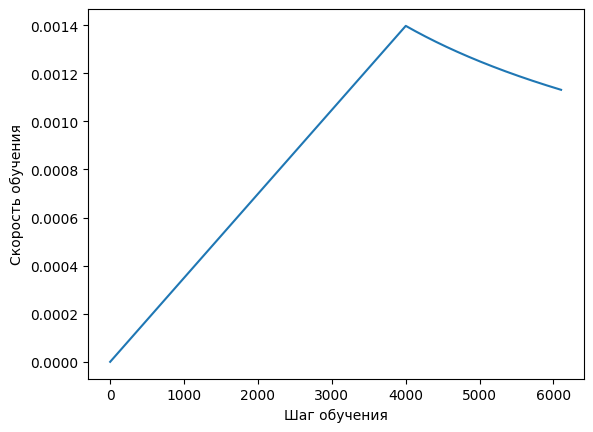

In [ ]:
# Скорость обучения на каждом шагу при учете, что мы планируем обучать на 10 эпохах:

plt.plot(learning_rate(tf.range(num_batches*EPOCHS, dtype=tf.float32)))
plt.ylabel('Скорость обучения')
plt.xlabel('Шаг обучения')

Функция потерь и метрики

In [ ]:
# Функция потерь с учетом маски
def masked_loss(label, pred):
  # Задаем маску, где метки не равны 0
  mask = label != 0
  # Определяем функцию потерь
  loss_object = tf.keras.losses.SparseCategoricalCrossentropy(
    from_logits=True, reduction='none')
  loss = loss_object(label, pred)

  # Важно чтобы mask и loss имели одинаковый тип данных
  mask = tf.cast(mask, dtype=loss.dtype)
  # Наложение маски на loss
  loss *= mask

  # Масштабирование потерь на маску
  loss = tf.reduce_sum(loss)/tf.reduce_sum(mask)
  return loss

# Функция точности с учетом маски
def masked_accuracy(label, pred):
  pred = tf.argmax(pred, axis=2)
  label = tf.cast(label, pred.dtype)
  # Оценка совпадения метки и предсказания
  match = label == pred
  # Задаем маску, где метки не равны 0
  mask = label != 0

  # Логическое И
  match = match & mask

  # Преобразуем к одному типу и масштабирование совпадений на маску
  match = tf.cast(match, dtype=tf.float32)
  mask = tf.cast(mask, dtype=tf.float32)
  return tf.reduce_sum(match)/tf.reduce_sum(mask)

Компилируем и обучаем модель

In [ ]:
transformer.compile(
    loss=masked_loss,
    optimizer=optimizer,
    metrics=[masked_accuracy])

In [ ]:
import os

checkpoint_path = "cp.weights.h5"
checkpoint_dir = os.path.dirname(checkpoint_path)

cp_callback = tf.keras.callbacks.ModelCheckpoint(filepath=checkpoint_path,
                                                 save_weights_only=True,
                                                 verbose=1)

In [ ]:
# transformer.load_weights(checkpoint_path)

In [ ]:
transformer.fit(train_batches,
                epochs=EPOCHS,
                validation_data=val_batches,
                callbacks=[cp_callback])

Epoch 1/8
764/764 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - loss: 7.9934 - masked_accuracy: 0.0551
Epoch 1: saving model to cp.weights.h5
764/764 ━━━━━━━━━━━━━━━━━━━━ 1050s 1s/step - loss: 7.9924 - masked_accuracy: 0.0551 - val_loss: 6.1399 - val_masked_accuracy: 0.1072
Epoch 2/8
764/764 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - loss: 5.9888 - masked_accuracy: 0.1150
Epoch 2: saving model to cp.weights.h5
764/764 ━━━━━━━━━━━━━━━━━━━━ 1022s 1s/step - loss: 5.9887 - masked_accuracy: 0.1150 - val_loss: 5.5951 - val_masked_accuracy: 0.1248
Epoch 3/8
764/764 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - loss: 5.4795 - masked_accuracy: 0.1366
Epoch 3: saving model to cp.weights.h5
764/764 ━━━━━━━━━━━━━━━━━━━━ 1013s 1s/step - loss: 5.4794 - masked_accuracy: 0.1366 - val_loss: 5.3179 - val_masked_accuracy: 0.1381
Epoch 4/8
764/764 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - loss: 5.1599 - masked_accuracy: 0.1514
Epoch 4: saving model to cp.weights.h5
764/764 ━━━━━━━━━━━━━━━━━━━━ 1011s 1s/step - loss: 5.1598 - masked_accuracy: 0.15

Выполнение модели (Inference)

In [ ]:
class Translator(tf.Module):
  def __init__(self, tokenizers, transformer):
    self.tokenizers = tokenizers
    self.transformer = transformer

  def __call__(self, sentence, max_length=MAX_TOKENS):

    assert isinstance(sentence, tf.Tensor) # Проверяем, что последовательность является тензором
    if len(sentence.shape) == 0:
      sentence = sentence[tf.newaxis]

    sentence = self.tokenizers.question.tokenize(sentence).to_tensor()
    # Введенное предложение написано на португальском языке
    encoder_input = sentence

    # Поскольку языком вывода является английский, инициализируйте вывод с помощью токена [START]
    start_end = self.tokenizers.answer.tokenize([''])[0]
    start = start_end[0][tf.newaxis]
    end = start_end[1][tf.newaxis]

    # Здесь требуется  tf.TensorArray` (вместо списка Python), чтобы динамический цикл
    # можно было отследить с помощью `tf.function`.
    output_array = tf.TensorArray(dtype=tf.int64, size=0, dynamic_size=True)
    output_array = output_array.write(0, start)

    for i in tf.range(max_length):
      # на каждом шаге складываем выходные токены в массив для
      #  передачи на вход на следующем шаге
      output = tf.transpose(output_array.stack())
      # передаем в трансформер для предсказания токены
      predictions = self.transformer([encoder_input, output], training=False)

      # Выбираем последний токен из измерения `seq_len`
      predictions = predictions[:, -1:, :]  # Форма `(batch_size, 1, vocab_size)`.

      # Предсказанный токен
      predicted_id = tf.argmax(predictions, axis=-1)

      # Объединяем `predicted_id` с выходными данными, которые передаются
      # декодеру в качестве входных данных.
      output_array = output_array.write(i+1, predicted_id[0])

      if predicted_id == end:
        break

    output = tf.transpose(output_array.stack())
    # Токены в текст
    text = tokenizers.answer.detokenize(output)[0]  # Shape: `()`.

    tokens = tokenizers.answer.lookup(output)[0]

    # `tf.function` не позволяет нам использовать значения attention_weight, которые были
    # рассчитаны на последней итерации цикла.
    # Поэтому пересчитаем их вне цикла.
    self.transformer([encoder_input, output[:,:-1]], training=False)
    attention_weights = self.transformer.decoder.last_attn_scores

    return text, tokens, attention_weights

In [ ]:
# Создадим экземпляр класса Translator и протестируем на нескольких фразах:
translator = Translator(tokenizers, transformer)

In [ ]:
def print_translation(sentence, tokens):
  print(f'{"Я:":25s}: {sentence}')
  print(f'{"Бот:":25s}: {tokens.numpy().decode("utf-8")}')

In [ ]:
sentence = 'Добрый день!'

translated_text, translated_tokens, attention_weights = translator(tf.constant(sentence))
print_translation(sentence, translated_text)

Я:                       : Добрый день!
Бот:                     : я тоже не умею


In [ ]:
sentence = 'что такое сладкий хлеб?'

translated_text, translated_tokens, attention_weights = translator(tf.constant(sentence))
print_translation(sentence, translated_text)

Я:                       : что такое сладкий хлеб?
Бот:                     : в спине , в следующем году , в сервисе , варене , варении , варенои , варенои , варенои , варенои , варе , варе , варе , версия , вла , версия , в


In [ ]:
sentence = 'Цель веб-студий?'

translated_text, translated_tokens, attention_weights = translator(tf.constant(sentence))
print_translation(sentence, translated_text)

Я:                       : Цель веб-студий?
Бот:                     : да , но не в россии .


In [ ]:
sentence = 'Сколько весит арбуз?'

translated_text, translated_tokens, attention_weights = translator(tf.constant(sentence))
print_translation(sentence, translated_text)

Я:                       : Сколько весит арбуз?
Бот:                     : в спине , антибиотики , и стандарте .


Экспорт модели

In [ ]:
# класс с именем ExportTranslator и наследуем его от tf.Module:

class ExportTranslator(tf.Module):
  def __init__(self, translator):
    self.translator = translator

  @tf.function(input_signature=[tf.TensorSpec(shape=[], dtype=tf.string)])
  def __call__(self, sentence):
    (result,
     tokens,
     attention_weights) = self.translator(sentence, max_length=MAX_TOKENS)

    return result

In [ ]:
translator = ExportTranslator(translator)

In [ ]:
tf.saved_model.save(translator, export_dir='translator')

In [ ]:
reloaded = tf.saved_model.load('translator')

In [ ]:
reloaded('Что такое телевизор?').numpy().decode("utf-8")

'вареное , и вареное , и вареное , и вареное , иогурт , и картофессионер .'